# Figure 3

Cells `7` and `15` are here only because cell `22` needs `fly_ids_sorted`

# Scutellum Height Oscillation and Walking vs. Running


In [12]:
### Setup — paths, imports
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from scipy import signal
from scipy.ndimage import uniform_filter1d, gaussian_filter1d
from scipy.signal import butter, filtfilt, hilbert
from scipy.stats import spearmanr, pearsonr, circmean, circstd
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Add 3d_tracking_dataset repo root so utils can be imported
_nb_dir = Path().resolve()
_repo_root = _nb_dir.parent if _nb_dir.name == 'notebooks' else _nb_dir
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))
import utils.io_dict_to_hdf5 as ioh5

# ── Edit these ────────────────────────────────────────────────────────────────

# H5_PATH    = Path("/home/user/3D_tracking_paper/IK_outputs/walking_videos/free_walking/Data_analysis/analysis/ik_output_combined_v1_free_walking.h5")
H5_PATH = Path('/mnt/lemebel/running_data/v1/ik_output_combined_v1_free_running_curated.h5') # all flies
OUTPUT_DIR = Path('/home/user/3D_tracking_paper/fig_3_output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FPS           = 800          # Hz
LEGS          = ['T1_left', 'T1_right', 'T2_left', 'T2_right', 'T3_left', 'T3_right']
REFERENCE_LEG = 'T1_left'
# Either front leg's liftoff can open a step cycle: whichever of the two lifts off
# first in a bout becomes that bout's reference, and its OWN next liftoff closes the
# cycle. So a cycle is a full stride of one leg (median ~94 ms), not a half-stride --
# an earlier version merged both legs' liftoffs into one sequence, which halved every
# cycle to ~46 ms and is NOT what this does. The two front legs run in near-perfect
# antiphase (measured L->R offset 0.500 of the stride, IQR 0.454-0.557), which is why
# merging them looked plausible.
REFERENCE_LEGS  = ['T1_left', 'T1_right']
MIN_CYCLE_SPEED = 5.0    # mm/s, mean thorax speed inside the cycle, else rejected
MIN_CYCLE_MS    = 20.0   # reject near-simultaneous L/R liftoffs (0.5% of events)
HEADING_BODIES = ['thorax']
SCALE         = 10.0         # model units → mm
SMOOTH_SIGMA  = 6            # Gaussian sigma (frames) for Hilbert phase


In [ ]:
# This cell sets global rcParams for all paper figures in the notebook.
# Re-run if you restart the kernel.
import matplotlib as _mpl
import matplotlib.font_manager as _fm
_fm.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/Arial.ttf")
_fm.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf")
_mpl.rcParams.update({
    'font.family':      'Arial',
    'font.size':        6,
    'axes.labelsize':   6,
    'axes.titlesize':   6,
    'xtick.labelsize':  6,
    'ytick.labelsize':  6,
    'legend.fontsize':  6,
    'pdf.fonttype':     42,
    'ps.fonttype':      42,
    'axes.linewidth':   0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size':  2,
    'ytick.major.size':  2,
    'lines.linewidth':  0.75,
})
print("Paper rcParams set: Arial 6 pt, pdf.fonttype=42")


Paper rcParams set: Arial 6 pt, pdf.fonttype=42


## Build df_valid from HDF5

Builds the per-frame DataFrame from the STAC IK output HDF5. Set `H5_PATH` in the Setup cell above, then run the next cell.

**Columns produced:**

| Column | Description |
|---|---|
| `bout_id` | HDF5 group key |
| `fly_id` | first token of `bout_id` split on `_` (edit `_parse_fly_id` if needed) |
| `frame` | 0-based frame index within bout |
| `thorax_z` | `xpos[:,1,2]` model units (Cell H1 multiplies by 10 → mm) |
| `forward_speed` | thorax XY displacement × FPS (mm/s) |
| `T1_left_phase` | linear phase in [−π, π] per T1L stride cycle; NaN outside complete cycles |
| `n_legs_stance` | legs in stance (0–6) per frame |
| `step_cycle_id` | integer cycle index from T1L swing onsets |
| `step_cycle_mean_speed` | mean forward_speed within each complete stride cycle |

**Site indices** (fruitfly_v1, verified from `fruitfly_v1_free.xml`):
`T1L=18, T1R=25, T2L=31, T2R=37, T3L=43, T3R=49` in `xpos_egocentric[:,idx,:]`

In [14]:
### Build df_valid — pipeline functions (mirrors Joint_Kinematics_Analysis)

# ── Data loading ──────────────────────────────────────────────────────────────
def load_ik_bouts(h5_path):
    d = ioh5.load(h5_path)
    bout_keys    = sorted(k for k in d if k.startswith('bout_'))
    fly_ids      = np.array(d['info']['fly_ids'])
    clip_lengths = np.array(d['info']['clip_lengths'])
    print(f"Loaded {len(bout_keys)} bouts | {len(np.unique(fly_ids))} unique flies")
    print(f"Frames/bout: min={clip_lengths.min()}, max={clip_lengths.max()}, "
          f"total={clip_lengths.sum():,}")
    return d, bout_keys, fly_ids, clip_lengths

_LEG_SHORT = {
    'T1_left':  'T1L', 'T1_right': 'T1R',
    'T2_left':  'T2L', 'T2_right': 'T2R',
    'T3_left':  'T3L', 'T3_right': 'T3R',
}

def find_leg_tip_site_indices(site_names, legs):
    indices = {}
    for leg in legs:
        short = _LEG_SHORT.get(leg, leg)
        patterns = [f"{short}_TaTip", f"{leg}_TaTip", f"claw_{leg}", f"{leg}_claw"]
        match = None
        for p in patterns:
            match = next((i for i, n in enumerate(site_names) if p in n), None)
            if match is not None:
                break
        indices[leg] = match
        if match is None:
            print(f"Warning: no tip site for {leg}")
    return indices

def bouts_to_dataframe(bout_dict, bout_keys, fly_ids, joint_list,
                       names_xpos, heading_bodies,
                       egocentric_site_names, leg_tip_site_indices):
    frames = []
    for bout_idx, (key, fly_id) in enumerate(zip(bout_keys, fly_ids)):
        b    = bout_dict[key]
        xpos = np.array(b['xpos'])
        T    = xpos.shape[0]
        row  = {
            'frame':    np.arange(T),
            'bout_idx': np.full(T, bout_idx, dtype=np.int32),
            'bout_id':  np.full(T, key, dtype=object),
            'fly_id':   np.full(T, fly_id, dtype=object),
        }
        if 'qpos' in b:
            qpos = np.array(b['qpos'])
            for leg, joint, idx in joint_list:
                row[f"{leg}_{joint}"] = qpos[:, idx]
        for body in heading_bodies:
            if body in names_xpos:
                bidx = names_xpos.index(body)
                row[f"{body}_x"] = xpos[:, bidx, 0]
                row[f"{body}_y"] = xpos[:, bidx, 1]
                row[f"{body}_z"] = xpos[:, bidx, 2]
        if 'xpos_egocentric' in b:
            xpos_ego = np.array(b['xpos_egocentric'])
            for leg, site_idx in leg_tip_site_indices.items():
                if site_idx is not None and site_idx < xpos_ego.shape[1]:
                    row[f"{leg}_tip_x_ego"] = xpos_ego[:, site_idx, 0]
                    row[f"{leg}_tip_y_ego"] = xpos_ego[:, site_idx, 1]
                    row[f"{leg}_tip_z_ego"] = xpos_ego[:, site_idx, 2]
        _CLAW_NAMES = {
            'T1_left': 'claw_T1_left', 'T1_right': 'claw_T1_right',
            'T2_left': 'claw_T2_left', 'T2_right': 'claw_T2_right',
            'T3_left': 'claw_T3_left', 'T3_right': 'claw_T3_right',
        }
        for leg, cname in _CLAW_NAMES.items():
            if cname in names_xpos:
                ci = names_xpos.index(cname)
                row[f"{leg}_tip_x_world"] = xpos[:, ci, 0]
                row[f"{leg}_tip_y_world"] = xpos[:, ci, 1]
                row[f"{leg}_tip_z_world"] = xpos[:, ci, 2]
        frames.append(pd.DataFrame(row))
    df = pd.concat(frames, ignore_index=True)
    print(f"Built DataFrame: {len(df):,} frames, {len(df.columns)} columns")
    return df

# ── Preprocessing ─────────────────────────────────────────────────────────────
def _gaussian_smooth(arr, sigma=4):
    mask = np.isnan(arr)
    out  = gaussian_filter1d(np.where(mask, 0., arr), sigma)
    cnt  = gaussian_filter1d((~mask).astype(float), sigma)
    out[cnt > 0] /= cnt[cnt > 0]
    out[mask]     = np.nan
    return out

def swing_onsets_from_stance(series):
    ss = series.values.astype(int)
    return np.where(np.diff(ss, prepend=ss[0]) == -1)[0]

def compute_swing_stance_tip_speed(df, legs, fps=800, thresh_frac=0.20):
    df = df.copy()
    for leg in legs:
        xcol, ycol, zcol = f"{leg}_tip_x_world", f"{leg}_tip_y_world", f"{leg}_tip_z_world"
        if zcol not in df.columns:
            continue
        ss = np.full(len(df), np.nan)
        for _bid, grp in df.groupby('bout_id', sort=False):
            idx = grp.index
            n   = len(grp)
            if n < 5:
                continue
            def _vel(col):
                v = grp[col].values.astype(float) if col in grp.columns else np.zeros(n)
                return np.gradient(v) * fps * 10
            spd = np.sqrt(_vel(xcol)**2 + _vel(ycol)**2 + _vel(zcol)**2)
            spd = _gaussian_smooth(spd, sigma=4)
            thr = thresh_frac * np.nanmax(spd)
            ss[idx] = (spd <= thr).astype(float)
        valid = ~np.isnan(ss)
        df.loc[valid, f"{leg}_swing_stance"] = ss[valid].astype(int)
    return df

def compute_n_legs_stance(df, legs):
    df = df.copy()
    cols = [f"{leg}_swing_stance" for leg in legs if f"{leg}_swing_stance" in df.columns]
    if cols:
        df['n_legs_stance'] = df[cols].sum(axis=1)
    return df

# ── Hilbert phase ─────────────────────────────────────────────────────────────
def compute_hilbert_phase_bout(positions_xyz, fps, smooth_sigma,
                               mask_stance=False, stance_speed_frac=0.20):
    """Per-frame Hilbert phase from 3-D tip speed.

    phase=0: mid-swing (peak speed).  phase=±π: mid-stance.
    Speed is mean-centered before Hilbert so phase spans full [-π, π].
    """
    T = len(positions_xyz)
    if T < 10:
        return np.full(T, np.nan), np.zeros(T)
    xyz = positions_xyz.astype(float).copy()
    for dim in range(3):
        col = xyz[:, dim]
        nans = np.isnan(col)
        if nans.any() and (~nans).sum() > 1:
            col[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), col[~nans])
        xyz[:, dim] = col
    vel = np.gradient(xyz, axis=0) * fps
    spd = gaussian_filter1d(np.linalg.norm(vel, axis=1), sigma=smooth_sigma)
    ph  = np.angle(hilbert(spd - np.nanmean(spd)))
    ph[:2] = np.nan; ph[-2:] = np.nan
    if mask_stance:
        ph[spd <= stance_speed_frac * np.nanmax(spd)] = np.nan
    return ph, spd

def swing_onsets_from_hilbert(phase):
    """Detect step-cycle boundaries (mid-swing) from 2π increments in unwrapped Hilbert phase."""
    finite_mask = np.isfinite(phase)
    if finite_mask.sum() < 4:
        return np.array([], dtype=int)
    finite_idx = np.where(finite_mask)[0]
    unwrapped  = np.unwrap(phase[finite_mask])
    jumps = np.where(np.diff(np.floor(unwrapped / (2 * np.pi))) > 0)[0]
    return finite_idx[jumps]

def compute_hilbert_phases(df, legs, fps, smooth_sigma):
    """Compute per-frame Hilbert phase for each leg using world-frame 3-D tip speed.

    Replaces linear-ramp compute_phases_from_swing.
    Convention: phase=0 mid-swing, phase=±π mid-stance.
    Processed per bout to avoid cross-bout edge effects.
    """
    df = df.copy()
    for leg in legs:
        df[f'{leg}_phase'] = np.nan
        x_col = f'{leg}_tip_x_world'
        y_col = f'{leg}_tip_y_world'
        z_col = f'{leg}_tip_z_world'
        if z_col not in df.columns:
            continue
        for bout_id, grp in df.groupby('bout_id', sort=False):
            xyz = grp[[x_col, y_col, z_col]].values
            ph, _ = compute_hilbert_phase_bout(xyz, fps, smooth_sigma, mask_stance=False)
            df.loc[grp.index, f'{leg}_phase'] = ph
    return df


def liftoff_from_hilbert(phase):
    """Upward crossing of phase = -π/2 → liftoff (swing onset)."""
    finite_mask = np.isfinite(phase)
    if finite_mask.sum() < 4:
        return np.array([], dtype=int)
    finite_idx = np.where(finite_mask)[0]
    unwrapped  = np.unwrap(phase[finite_mask])
    increments = np.diff(np.floor((unwrapped + np.pi / 2) / (2 * np.pi)))
    return finite_idx[np.where(increments > 0)[0]]


def landing_from_hilbert(phase):
    """Upward crossing of phase = +π/2 → landing (stance onset)."""
    finite_mask = np.isfinite(phase)
    if finite_mask.sum() < 4:
        return np.array([], dtype=int)
    finite_idx = np.where(finite_mask)[0]
    unwrapped  = np.unwrap(phase[finite_mask])
    increments = np.diff(np.floor((unwrapped - np.pi / 2) / (2 * np.pi)))
    return finite_idx[np.where(increments > 0)[0]]


def compute_swing_stance_from_hilbert(df, legs):
    """Derive binary swing/stance from Hilbert phase.

    swing  (0): |phase| < π/2  — near mid-swing (peak speed)
    stance (1): |phase| >= π/2 — near mid-stance (speed trough)

    Replaces compute_swing_stance_tip_speed. Must be called after
    compute_hilbert_phases.
    """
    df = df.copy()
    for leg in legs:
        phase_col = f'{leg}_phase'
        if phase_col not in df.columns:
            continue
        ph = df[phase_col].values
        ss = np.where(np.isfinite(ph), (np.abs(ph) >= np.pi / 2).astype(float), np.nan)
        df[f'{leg}_swing_stance'] = ss
    return df



def compute_heading_and_velocity(df, fps=800, body='thorax', smooth_sigma=2):
    df = df.copy()
    x_col, y_col = f"{body}_x", f"{body}_y"
    if x_col not in df.columns or y_col not in df.columns:
        print(f"Warning: position columns not found for {body}")
        return df
    heading_arr   = np.full(len(df), np.nan)
    speed_arr     = np.full(len(df), np.nan)
    turn_rate_arr = np.full(len(df), np.nan)
    for bout_id, grp in df.groupby('bout_id'):
        idx = grp.index
        x   = gaussian_filter1d(grp[x_col].values.astype(float), sigma=smooth_sigma)
        y   = gaussian_filter1d(grp[y_col].values.astype(float), sigma=smooth_sigma)
        dx  = np.gradient(x) * fps
        dy  = np.gradient(y) * fps
        heading   = np.arctan2(dy, dx)
        heading_u = np.unwrap(heading)
        heading_s = gaussian_filter1d(heading_u, sigma=smooth_sigma)
        heading_s = (heading_s + np.pi) % (2 * np.pi) - np.pi
        heading_arr[idx]   = heading_s
        speed_arr[idx]     = np.sqrt(dx**2 + dy**2) * 10   # mm/s
        turn_rate_arr[idx] = np.gradient(heading_s) * fps
    df['heading']       = heading_arr
    df['forward_speed'] = speed_arr
    df['turning_rate']  = turn_rate_arr
    return df

def compute_step_cycle_speed(df, fps=800, ref_legs=None,
                             min_speed=None, min_ms=None):
    """Step cycles bounded by liftoffs of EITHER front leg, gated on body speed.

    Two changes from the earlier version, which used T1_left liftoffs only and
    accepted every cycle it found:

    1. EITHER front leg can initiate. Per bout, the leg that lifts off first
       becomes the reference, and each cycle runs from one of ITS liftoffs to the
       next -- a full stride, median 94 ms. Which leg leads is close to a coin
       flip across bouts (T1_left 1116, T1_right 1110), and letting the leading
       leg define the cycle recovers 5701 cycles against 5201 for T1_left only:
       in a right-led bout, T1_left's first liftoff comes later and the opening
       stride was being lost. `step_cycle_leg` records the reference leg.
       NOTE: this is NOT a merge of both legs' liftoffs. Merging would bound each
       cycle by the OTHER leg's next liftoff, halving it to ~46 ms, because the
       front legs run in near-perfect antiphase (L->R offset 0.500 of the stride,
       IQR 0.454-0.557).

    2. A cycle is kept only if mean thorax speed inside it exceeds `min_speed`.
       The Hilbert phase has no amplitude gate, so a standing fly still
       accumulates 2*pi and still yields liftoffs: bout_0807 reported 14 of them
       with the body moving for exactly one. Cycles shorter than `min_ms` are
       dropped too -- those are near-simultaneous L/R events, not steps.
    """
    df = df.copy()
    ref_legs  = REFERENCE_LEGS  if ref_legs  is None else ref_legs
    min_speed = MIN_CYCLE_SPEED if min_speed is None else min_speed
    min_ms    = MIN_CYCLE_MS    if min_ms    is None else min_ms

    sc_id  = np.full(len(df), np.nan)
    sc_spd = np.full(len(df), np.nan)
    sc_leg = np.full(len(df), '', dtype=object)
    n_kept = n_slow = n_short = 0

    for bout_id, grp in df.groupby('bout_id', sort=False):
        idx = grp.index
        per_leg = {}
        for leg in ref_legs:
            pcol = f'{leg}_phase'
            if pcol in grp.columns:
                on = liftoff_from_hilbert(grp[pcol].values)
                if len(on):
                    per_leg[leg] = on
        if not per_leg:
            continue
        # whichever leg lifts off FIRST in this bout defines the cycles, and each
        # cycle is closed by that SAME leg's next liftoff -- so a cycle is a full
        # stride, not a half-stride. Ties fall to the order of ref_legs.
        ref = min(per_leg, key=lambda l: per_leg[l][0])
        onsets = per_leg[ref]
        if len(onsets) < 2:
            continue
        events = [(int(t), ref) for t in onsets]
        spd = (grp['forward_speed'].values.astype(float)
               if 'forward_speed' in grp.columns else np.full(len(grp), np.nan))
        k = 0
        for (t0, leg), (t1, _) in zip(events[:-1], events[1:]):
            if (t1 - t0) / fps * 1000.0 < min_ms:
                n_short += 1
                continue
            mspd = np.nanmean(spd[t0:t1])
            if not np.isfinite(mspd) or mspd < min_speed:
                n_slow += 1
                continue
            sc_id[idx[t0:t1]]  = k
            sc_spd[idx[t0:t1]] = mspd
            sc_leg[idx[t0:t1]] = leg
            k += 1
            n_kept += 1

    df['step_cycle_id']         = sc_id
    df['step_cycle_mean_speed'] = sc_spd
    df['step_cycle_leg']        = sc_leg
    print(f"Step cycles: {n_kept} kept from legs {ref_legs}"
          f" | rejected {n_slow} below {min_speed} mm/s thorax speed,"
          f" {n_short} shorter than {min_ms:.0f} ms")
    return df

# ── Build df_valid ────────────────────────────────────────────────────────────
bout_dict, bout_keys, fly_ids, clip_lengths = load_ik_bouts(H5_PATH)
names_qpos            = list(bout_dict['info']['names_qpos'])
names_xpos            = list(bout_dict['info']['names_xpos'])
egocentric_site_names = list(bout_dict['info']['site_names_egocentric'])

leg_tip_site_indices = find_leg_tip_site_indices(egocentric_site_names, LEGS)
print(f"Leg tip site indices: {leg_tip_site_indices}")

# No joint angles needed for this analysis — pass empty joint_list
df = bouts_to_dataframe(
    bout_dict, bout_keys, fly_ids, joint_list=[],
    names_xpos=names_xpos,
    heading_bodies=HEADING_BODIES,
    egocentric_site_names=egocentric_site_names,
    leg_tip_site_indices=leg_tip_site_indices,
)

df = compute_hilbert_phases(df, LEGS, fps=FPS, smooth_sigma=SMOOTH_SIGMA)
df = compute_swing_stance_from_hilbert(df, LEGS)
df = compute_n_legs_stance(df, LEGS)
df = compute_heading_and_velocity(df, fps=FPS, body=HEADING_BODIES[0])
df = compute_step_cycle_speed(df, fps=FPS)

# thorax_z is in model metres; * SCALE gives mm  (SCALE=10 → mm)
df_valid = df.copy()
print(f"\ndf_valid: {len(df_valid):,} rows | "
      f"{df_valid['bout_id'].nunique()} bouts | "
      f"{df_valid['fly_id'].nunique()} flies")
print(f"  thorax_z:              mean={df_valid['thorax_z'].mean():.4f} model-m  "
      f"({df_valid['thorax_z'].mean()*SCALE:.3f} mm)")
print(f"  forward_speed (mm/s):  {df_valid['forward_speed'].mean():.1f} ± "
      f"{df_valid['forward_speed'].std():.1f}")
print(f"  T1_left_phase valid:   "
      f"{df_valid['T1_left_phase'].notna().mean()*100:.1f}% of frames")
print(f"  step_cycle_mean_speed: "
      f"{df_valid['step_cycle_mean_speed'].notna().mean()*100:.1f}% of frames")


Loaded 2213 bouts | 53 unique flies
Frames/bout: min=64, max=1562, total=653,919
Leg tip site indices: {'T1_left': 18, 'T1_right': 25, 'T2_left': 31, 'T2_right': 37, 'T3_left': 43, 'T3_right': 49}
Built DataFrame: 653,919 frames, 43 columns
Step cycles: 5658 kept from legs ['T1_left', 'T1_right'] | rejected 106 below 5.0 mm/s thorax speed, 1 shorter than 20 ms

df_valid: 653,919 rows | 2213 bouts | 53 flies
  thorax_z:              mean=0.2234 model-m  (2.234 mm)
  forward_speed (mm/s):  17.8 ± 9.9
  T1_left_phase valid:   98.6% of frames
  step_cycle_mean_speed: 69.7% of frames


In [15]:
### Cell H1 — Add detrended thorax height to df_valid

df_valid['thorax_z_mm'] = df_valid['thorax_z'] * 10.0   # model-m → mm

BASELINE_FRAMES = int(0.100 * FPS)   # 80 frames — 100 ms rolling window

df_valid['thorax_z_baseline']  = np.nan
df_valid['thorax_z_detrended'] = np.nan

for bid, grp in df_valid.groupby('bout_id', sort=False):
    idx      = grp.index
    z_mm     = grp['thorax_z_mm'].values
    baseline = uniform_filter1d(z_mm, size=BASELINE_FRAMES, mode='nearest')
    df_valid.loc[idx, 'thorax_z_baseline']  = baseline
    df_valid.loc[idx, 'thorax_z_detrended'] = z_mm - baseline

# Bandpass oscillatory component (5–50 Hz — stride frequency band at 800 Hz)
b_bp, a_bp = butter(3, [5 / (FPS / 2), 50 / (FPS / 2)], btype='band')

df_valid['thorax_z_osc'] = np.nan
for bid, grp in df_valid.groupby('bout_id', sort=False):
    idx = grp.index
    if len(idx) < 30:
        continue
    df_valid.loc[idx, 'thorax_z_osc'] = filtfilt(b_bp, a_bp, grp['thorax_z_mm'].values)

print(f"thorax_z_mm:        mean={df_valid['thorax_z_mm'].mean():.3f} mm  "
      f"std={df_valid['thorax_z_mm'].std():.3f} mm")
print(f"thorax_z_detrended: mean≈0  std={df_valid['thorax_z_detrended'].std():.4f} mm")
print(f"thorax_z_osc:       mean≈0  std={df_valid['thorax_z_osc'].std():.4f} mm")

thorax_z_mm:        mean=2.234 mm  std=0.177 mm
thorax_z_detrended: mean≈0  std=0.0260 mm
thorax_z_osc:       mean≈0  std=0.0264 mm


Mean touchdown phase: 1.624 rad  (93.0°)


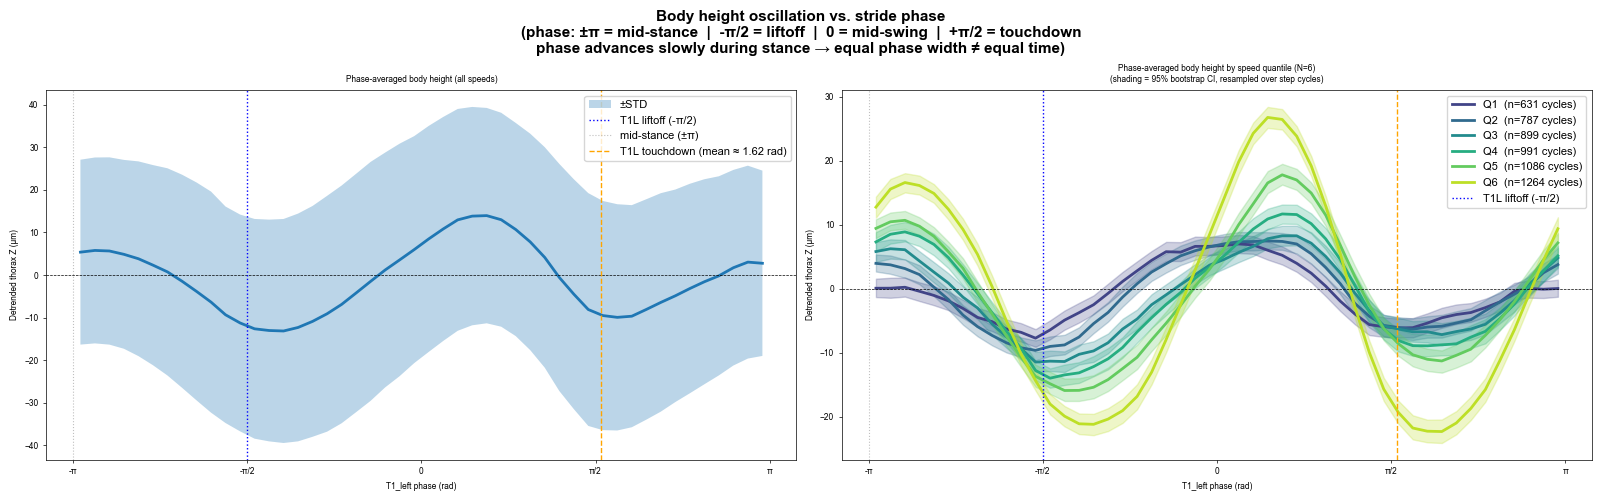

In [ ]:
### Cell H2 — BUILDS FOR THE FIGURES, NOT IN PAPER Phase-averaged height oscillation

N_BINS      = 48
N_QUANTILES = 6   # ← change this: 3=terciles, 4=quartiles, 5=quintiles, etc.

phase_bins  = np.linspace(-np.pi, np.pi, N_BINS + 1)
bin_centers = 0.5 * (phase_bins[:-1] + phase_bins[1:])
bin_idx     = np.clip(np.digitize(df_valid['T1_left_phase'], phase_bins) - 1, 0, N_BINS - 1)

# Dynamic labels
_q_labels = [f'Q{i+1}' for i in range(N_QUANTILES)]
if N_QUANTILES == 3:
    _q_labels = ['slow', 'medium', 'fast']
elif N_QUANTILES == 4:
    _q_labels = ['slow', 'med-slow', 'med-fast', 'fast']

speed_quantiles  = pd.qcut(df_valid['step_cycle_mean_speed'], q=N_QUANTILES,
                            labels=_q_labels)
df_valid['_sq'] = speed_quantiles

# Mean speed per quantile (used later for peak analysis)
_mean_speed_per_q = (df_valid.groupby('_sq', observed=True)['step_cycle_mean_speed']
                     .mean().to_dict())

# Compute mean touchdown phase (swing→stance transition) from T1_left data
_td_phases_list = []
for _bid, _grp in df_valid.groupby('bout_id', sort=False):
    if 'T1_left_swing_stance' not in _grp.columns:
        continue
    _ss = _grp['T1_left_swing_stance'].values.astype(int)
    _ph = _grp['T1_left_phase'].values
    _td_frames = np.where(np.diff(_ss, prepend=_ss[0]) == 1)[0]
    for _tf in _td_frames:
        if _tf < len(_ph) and not np.isnan(_ph[_tf]):
            _td_phases_list.append(_ph[_tf])

mean_td_phase = circmean(_td_phases_list, high=np.pi, low=-np.pi) if _td_phases_list else None
print(f"Mean touchdown phase: {mean_td_phase:.3f} rad  ({np.degrees(mean_td_phase):.1f}°)" if mean_td_phase is not None else "No touchdown phase computed")

z_vals = df_valid['thorax_z_detrended'].values * 1000   # mm → µm

# ── Bootstrap helper (resamples step cycles) ─────────────────────────────────
def _bootstrap_tercile_ci(tercile_mask, n_boot=1000, ci=95, seed=42):
    """Bootstrap CI over step cycles for a subset of df_valid rows.

    Resamples STEP CYCLES (not frames) to respect within-cycle correlations.
    Returns (mean, lo, hi) each shape (N_BINS,).
    """
    sub = df_valid[tercile_mask].dropna(subset=['step_cycle_id', 'T1_left_phase'])
    cycle_groups = list(sub.groupby(['bout_id', 'step_cycle_id']))
    n_cyc = len(cycle_groups)
    if n_cyc < 2:
        nans = np.full(N_BINS, np.nan)
        return nans, nans, nans

    cyc_mat = np.full((n_cyc, N_BINS), np.nan)
    for ci_i, (_, grp) in enumerate(cycle_groups):
        grp_pos = df_valid.index.get_indexer(grp.index)
        _b = bin_idx[grp_pos]
        _z = grp['thorax_z_detrended'].values * 1000
        for b in range(N_BINS):
            vals = _z[_b == b]
            if len(vals):
                cyc_mat[ci_i, b] = np.nanmean(vals)

    rng  = np.random.default_rng(seed)
    boot = np.full((n_boot, N_BINS), np.nan)
    for i in range(n_boot):
        idx     = rng.integers(0, n_cyc, size=n_cyc)
        boot[i] = np.nanmean(cyc_mat[idx], axis=0)

    half = (100 - ci) / 2
    mean = np.nanmean(cyc_mat, axis=0)
    lo   = np.nanpercentile(boot, half,       axis=0)
    hi   = np.nanpercentile(boot, 100 - half, axis=0)
    return mean, lo, hi

colors_q = plt.cm.viridis(np.linspace(0.2, 0.9, N_QUANTILES))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: overall phase average ───────────────────────────────────────────────
z_phase = np.array([z_vals[bin_idx == b].mean() for b in range(N_BINS)])
z_std   = np.array([z_vals[bin_idx == b].std()  for b in range(N_BINS)])
axes[0].fill_between(bin_centers, z_phase - z_std, z_phase + z_std, alpha=0.3, label='±STD')
axes[0].plot(bin_centers, z_phase, lw=2)
axes[0].axhline(0, color='k', lw=0.5, ls='--')
axes[0].axvline(-np.pi/2, color='blue', ls=':', lw=1, label='T1L liftoff (-π/2)')
axes[0].axvline(-np.pi,  color='gray',  ls=':', lw=0.8, alpha=0.5, label='mid-stance (±π)')
if mean_td_phase is not None:
    axes[0].axvline(mean_td_phase, color='orange', ls='--', lw=1,
                    label=f'T1L touchdown (mean ≈ {mean_td_phase:.2f} rad)')
axes[0].set_xlabel('T1_left phase (rad)'); axes[0].set_ylabel('Detrended thorax Z (µm)')
axes[0].set_title('Phase-averaged body height (all speeds)')
axes[0].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
axes[0].set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
axes[0].legend(fontsize=8)

# ── Right: by speed quantile + bootstrap 95% CI ───────────────────────────────
_z_phase_q_stored = {}
for qi, (qlabel, _) in enumerate(df_valid.groupby('_sq', observed=True)):
    mask = df_valid['_sq'] == qlabel
    qmean, qlo, qhi = _bootstrap_tercile_ci(mask)
    n_cyc = len(list(df_valid[mask].dropna(subset=['step_cycle_id'])
                     .groupby(['bout_id', 'step_cycle_id'])))
    axes[1].fill_between(bin_centers, qlo, qhi,
                         color=colors_q[qi], alpha=0.25)
    axes[1].plot(bin_centers, qmean,
                 color=colors_q[qi], lw=2,
                 label=f'{qlabel}  (n={n_cyc} cycles)')
    _z_phase_q_stored[qlabel] = qmean

axes[1].axhline(0, color='k', lw=0.5, ls='--')
axes[1].axvline(-np.pi/2, color='blue', ls=':', lw=1, label='T1L liftoff (-π/2)')
axes[1].axvline(-np.pi,  color='gray',  ls=':', lw=0.8, alpha=0.5)
if mean_td_phase is not None:
    axes[1].axvline(mean_td_phase, color='orange', ls='--', lw=1)
axes[1].set_xlabel('T1_left phase (rad)'); axes[1].set_ylabel('Detrended thorax Z (µm)')
axes[1].set_title(f'Phase-averaged body height by speed quantile (N={N_QUANTILES})\n'
                  '(shading = 95% bootstrap CI, resampled over step cycles)')
axes[1].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
axes[1].set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
axes[1].legend(fontsize=8)

plt.suptitle('Body height oscillation vs. stride phase\n'
             '(phase: ±π = mid-stance  |  -π/2 = liftoff  |  0 = mid-swing  |  +π/2 = touchdown\n'
             'phase advances slowly during stance → equal phase width ≠ equal time)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'height_phase_avg.pdf', bbox_inches='tight')
plt.show()

_z_phase_stored = z_phase.copy()

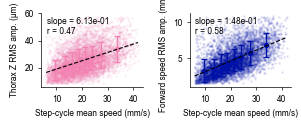

In [ ]:
# Cell H6 — Amplitude of oscillation vs. speed 

from scipy.stats import linregress as _linregress

# Compute speed oscillation inline if Cell S0 hasn't run
if 'forward_speed_osc' not in df_valid.columns:
    df_valid['forward_speed_osc'] = (
        df_valid['forward_speed'] - df_valid['step_cycle_mean_speed'])

cycle_amp = df_valid.groupby(['bout_id', 'step_cycle_id']).agg(
    speed   =('step_cycle_mean_speed', 'first'),
    z_amp   =('thorax_z_detrended',  lambda x: np.sqrt(np.nanmean(x**2)) * 1000),
    spd_amp =('forward_speed_osc',  lambda x: np.sqrt(np.nanmean(x**2))),
    fly_id  =('fly_id', 'first'),
).reset_index().dropna()

fig, axes = plt.subplots(1, 2, figsize=(2 * 38 / 25.4, 32 / 25.4))

for ax, ycol, ylabel, color in [
    (axes[0], 'z_amp',   u'Thorax Z RMS amp. (µm)',  '#f282b4'),
    (axes[1], 'spd_amp', 'Forward speed RMS amp. (mm/s)', '#0011a7'),
]:
    x = cycle_amp['speed'].values
    y = cycle_amp[ycol].values

    # Clip outliers to 1–99th percentile
    xlo, xhi = np.percentile(x, 1), np.percentile(x, 99)
    ylo, yhi = np.percentile(y, 1), np.percentile(y, 99)
    ok = (x >= xlo) & (x <= xhi) & (y >= ylo) & (y <= yhi)
    xc, yc = x[ok], y[ok]

    # Scatter (rasterized at 300 dpi for clean PDF export)
    ax.scatter(xc, yc, s=1, alpha=0.08, color=color, rasterized=True, zorder=1)

    # Binned mean ± STD (8 quantile bins)
    _df  = pd.DataFrame({'speed': xc, 'amp': yc})
    _bins = pd.qcut(_df['speed'], q=8)
    _agg  = _df.groupby(_bins, observed=True)['amp'].agg(['mean', 'std'])
    _spdc = _df.groupby(_bins, observed=True)['speed'].mean()
    ax.errorbar(_spdc, _agg['mean'], yerr=_agg['std'],
                fmt='o', color=color, lw=1.0, ms=3, capsize=2, zorder=5)

    # Linear regression
    sl, ic, r, p, _ = _linregress(xc, yc)
    _xs = np.linspace(xc.min(), xc.max(), 100)
    ax.plot(_xs, sl * _xs + ic, color='k', lw=0.8, ls='--', zorder=6)
    ax.text(0.05, 0.95, f'slope = {sl:.2e}\nr = {r:.2f}',
            transform=ax.transAxes, va='top')

    ax.set_xlabel('Step-cycle mean speed (mm/s)')
    ax.set_ylabel(ylabel)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'height_oscillation_amplitude.pdf', bbox_inches='tight', dpi=300)
plt.show()


In [ ]:
### Cell P0 — Peak phase extraction → df_pt   (detect bout-wide, then slice by cycle)
# Requires: H2 (N_QUANTILES, _q_labels), step_cycle_id, forward_speed
# smooth the whole bout ONCE, find peaks on the continuous trace, then assign
# each peak to whichever cycle contains it. Three consequences.
#   - No cap. A cycle can yield 1, 2 or 3 peaks and the count is informative.
#     Measured: 1.60 peaks/cycle for height, 2.03 for speed.
#   - Prominence is a physical threshold, not a per-slice accident: 2x the noise
#     floor for height, 1.5 mm/s for speed.
#   - Gaps are INTERPOLATED, not replaced by 0.0. The old code did
#     np.where(valid, sig, 0.0), and for a mean-centred signal 0 is mid-range, so
#     every NaN run manufactured a peak at its edges.
#
# Speed peaks are found on RAW forward_speed rather than forward_speed_osc: B is a
# bout-wide method and the oscillation has a step at every cycle boundary. Within a
# cycle the two give the same peak positions (subtracting a per-cycle constant
# cannot move a local maximum), and measured bout-wide they agree to 2.11 vs 2.10
# peaks/cycle -- so this is for cleanliness, not because the steps misbehave.
#

from scipy.signal import find_peaks

# ── Config ────────────────────────────────────────────────────────────────
N_Q_POLAR     = 3      # ← number of speed quantiles for polar plots
PEAK_SMOOTH   = 3      # frames, Gaussian sigma applied to the WHOLE bout trace
Z_PROM        = 9.8    # µm   = 2 x the 4.9 µm keypoint noise floor (Cell J0)
SPD_PROM      = 1.5    # mm/s
PEAK_MIN_DIST = 15     # frames — min separation between peaks
fly_ids_sorted = sorted(df_valid['fly_id'].unique())
_q_labels_polar = (
    ['slow', 'medium', 'fast'] if N_Q_POLAR == 3
    else ['slow', 'fast'] if N_Q_POLAR == 2
    else [f'Q{i+1}' for i in range(N_Q_POLAR)]
)

# ── Detect per bout, assign per cycle ─────────────────────────────────────
pt_records = []
_n_cyc_seen = 0
for _bid, _bg in df_valid.groupby('bout_id', sort=False):
    _phase = _bg['T1_left_phase'].to_numpy()
    _cid   = _bg['step_cycle_id'].to_numpy()
    _spdm  = _bg['step_cycle_mean_speed'].to_numpy()
    _fly   = _bg['fly_id'].iloc[0]
    _cyc_ids = np.unique(_cid[np.isfinite(_cid)])
    if _cyc_ids.size == 0:
        continue
    _n_cyc_seen += _cyc_ids.size

    _signals = [
        ('height', _bg['thorax_z_detrended'].to_numpy() * 1000, Z_PROM),
        ('speed',  _bg['forward_speed'].to_numpy(),             SPD_PROM),
    ]
    for _name, _raw, _prom in _signals:
        _s = np.asarray(_raw, dtype=float).copy()
        _ok = np.isfinite(_s)
        if _ok.sum() < 20:
            continue
        # interpolate across gaps rather than substituting a mid-range constant
        if (~_ok).any():
            _s[~_ok] = np.interp(np.flatnonzero(~_ok), np.flatnonzero(_ok), _s[_ok])
        _s = gaussian_filter1d(_s, PEAK_SMOOTH)
        _pks, _props = find_peaks(_s, prominence=_prom, distance=PEAK_MIN_DIST)
        if _pks.size == 0:
            continue
        _pk_cid = _cid[_pks]
        for _c in _cyc_ids:
            _sel = np.flatnonzero(_pk_cid == _c)
            if _sel.size == 0:
                continue
            _order = _sel[np.argsort(_pks[_sel])]        # earliest first
            _ms = _spdm[_cid == _c]
            _ms = _ms[np.isfinite(_ms)]
            if _ms.size == 0:
                continue
            for _rank, _j in enumerate(_order):
                _p = _pks[_j]
                if not np.isfinite(_phase[_p]):
                    continue
                pt_records.append(dict(
                    signal=_name, peak_rank=_rank,
                    phase=float(_phase[_p]),
                    prominence=float(_props['prominences'][_j]),
                    n_in_cycle=int(_order.size),
                    bout_id=_bid, step_cycle_id=float(_c),
                    fly_id=_fly, mean_speed=float(_ms[0]),
                ))

df_pt = pd.DataFrame(pt_records)
df_pt['speed_q'] = pd.qcut(
    df_pt['mean_speed'], q=N_Q_POLAR, labels=_q_labels_polar
)
quantile_order_polar = _q_labels_polar
colors_q_polar = plt.cm.viridis(np.linspace(0.2, 0.9, N_Q_POLAR))

print(f'df_pt: {len(df_pt)} peaks from {_n_cyc_seen} cycles')
print(df_pt.groupby(['signal', 'peak_rank']).size().rename('n').to_string())
print('\npeaks per cycle, and how many cycles yielded each count:')
for _sig in ('height', 'speed'):
    _d = df_pt[df_pt['signal'] == _sig]
    if _d.empty:
        continue
    _per = _d.groupby(['bout_id', 'step_cycle_id']).size()
    _hist = _per.value_counts().sort_index()
    print(f"  {_sig:<7} {len(_d)/_n_cyc_seen:.2f}/cycle | "
          + '  '.join(f'{k} peak{"s" if k > 1 else " "}: {v}' for k, v in _hist.items())
          + f" | cycles with none: {_n_cyc_seen - len(_per)}")
print(f"  prominence used: height {Z_PROM} µm (2x the {Z_PROM/2:.1f} µm noise floor), "
      f"speed {SPD_PROM} mm/s | smoothing σ = {PEAK_SMOOTH} frames")


df_pt: 21205 peaks from 5658 cycles
signal  peak_rank
height  0            5583
        1            3795
        2             244
        3              17
        4               1
speed   0            5619
        1            4860
        2             988
        3              92
        4               4
        5               1
        6               1

peaks per cycle, and how many cycles yielded each count:
  height  1.70/cycle | 1 peak : 1788  2 peaks: 3551  3 peaks: 227  4 peaks: 16  5 peaks: 1 | cycles with none: 75
  speed   2.04/cycle | 1 peak : 759  2 peaks: 3872  3 peaks: 896  4 peaks: 88  5 peaks: 3  7 peaks: 1 | cycles with none: 39
  prominence used: height 9.8 µm (2x the 4.9 µm noise floor), speed 1.5 mm/s | smoothing σ = 3 frames


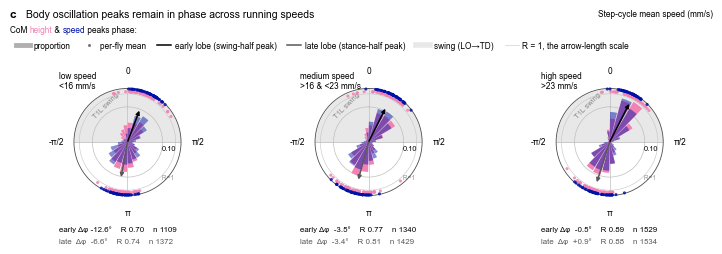

paired lobe stats  (8313 lobe-pairs from 5655 cycles)
quantile  lobe      shared       Δφ  % stride      R      n
slow      early     +20.7°   -12.6°      -3.5   0.70   1109
slow      late     -169.7°    -6.6°      -1.8   0.74   1372
medium    early     +26.6°    -3.5°      -1.0   0.77   1340
medium    late     -164.8°    -3.4°      -0.9   0.81   1429
fast      early     +27.0°    -0.5°      -0.1   0.89   1529
fast      late     -162.2°    +0.9°      +0.3   0.88   1534
  Δφ = height − speed, so negative means height peaks first.
  R  = concentration of the PAIRED difference (0 = no fixed offset, 1 = locked).


In [ ]:
#  Polar rose plots: one per speed quantile, height vs. speed overlaid
# Roses: pink = height peaks, blue-violet = speed peaks (both lobes pooled into one rose).
#
# ONE arrow per lobe, reporting the height-vs-speed relationship directly.
#   direction = the phase the two signals SHARE -- per cycle, the circular midpoint
#               angle(exp(i*ph_height) + exp(i*ph_speed)), averaged over cycles. It
#               necessarily lands between the two signal means, and it lands at
#               89-100% of peak rose density in every panel.
#   length    = R of the paired Dphi in that lobe, against the faint R = 1 ring. Not the
#               concentration of either distribution on its own: the reproducibility of
#               the OFFSET, which is what the arrow is there to report.
#
# Lobes split at +-pi/2, which is exactly LO and TD: the cycle opens at reference-leg
# liftoff (phase -pi/2) and runs -pi/2 -> 0 (mid-swing) -> +pi/2 (TD) -> +pi (mid-stance),
# so |phase| < pi/2 is the swing-half peak (early, first along the cycle) and |phase| >=
# pi/2 is the stance-half peak (late). The shaded half of each circle marks that same
# swing window, so it delineates the two lobes for free: black arrow inside the shading,
# grey arrow outside it.
#
# Because a lobe pins down WHICH bump is being compared, the half-stride ambiguity is
# gone and Dphi is an ordinary directional quantity -- plain circular mean, plain R, no
# doubled angles. Measured R is 0.69-0.89 per lobe against an axial R2 of 0.60-0.78 on
# the same peaks, so pooling the lobes was costing concentration.
#
# Where a lobe holds more than one peak of the same signal the most prominent is taken
# (5.4% of height lobes, 13.9% of speed lobes); pairing by nearest-in-phase instead moves
# every Dphi by less than 1.5 deg.
#
# Per-fly dots: one per fly per signal per lobe, at a single radius outside the R = 1
# ring. They answer a different question from the arrow -- WHERE each fly's peaks sit --
# so the two are complementary: dots show the spread of position across flies, the arrow
# shows the height-vs-speed offset and how reproducible it is.

from scipy.stats import circmean

# ── Style ─────────────────────────────────────────────────────────────────────
try:
    import matplotlib.font_manager as _fmd
    _fmd.fontManager.addfont('/usr/share/fonts/truetype/msttcorefonts/Arial.ttf')
except Exception:
    pass

FIG_W_MM, FIG_H_MM = 180, 68     # whole panel, all quantiles side by side
FS                 = 6           # pt
PANEL_LETTER       = 'c'
PANEL_TITLE        = 'Body oscillation peaks remain in phase across running speeds'
PANEL_CORNER       = 'Step-cycle mean speed (mm/s)'

N_PBINS    = 24
bin_edges  = np.linspace(-np.pi, np.pi, N_PBINS + 1)
bin_width  = 2 * np.pi / N_PBINS
theta_ctrs = 0.5 * (bin_edges[:-1] + bin_edges[1:])

HEIGHT_COLOR = '#f282b4';  HEIGHT_ALPHA = 1.0
SPEED_COLOR  = '#0011a7';  SPEED_ALPHA  = round(0x7c / 255, 3)  # 0.486
EARLY_C, LATE_C = '#000000', '#595959'      # the two lobe arrows
SHADE_C, RING_C, SPINE_C, GRID_C = '#E8E8E8', '#C4C4C4', '#4D4D4D', '#BFBFBF'
R_UNIT_FRAC = 0.90               # radius that means R = 1
R_DOT_H     = 0.94               # radius for the per-fly HEIGHT mean dots
R_DOT_S     = 0.99               # radius for the per-fly SPEED  mean dots
DOT_S       = 5                  # points^2
DOT_MIN_N   = 2                  # peaks a fly needs in a lobe to get a dot

_LOBES = (('early', EARLY_C), ('late', LATE_C))


def _circ(v):
    """circular mean and mean resultant length of directional angles."""
    _z = np.mean(np.exp(1j * np.asarray(v, dtype=float)))
    return np.angle(_z), np.abs(_z)


# ── Pair height against speed inside each lobe of each cycle ──────────────────
_pt = df_pt.copy()
_pt['lobe'] = np.where(np.abs(_pt['phase']) < np.pi / 2, 'early', 'late')
_keys = ['speed_q', 'bout_id', 'step_cycle_id', 'lobe']
_best = _pt.loc[_pt.groupby(_keys + ['signal'], observed=True)['prominence'].idxmax()]
_pair = (_best.set_index(_keys + ['signal'])['phase']
              .unstack('signal')
              .dropna(subset=['height', 'speed'])
              .reset_index())
_pair['dphi'] = np.angle(np.exp(1j * (_pair['height'] - _pair['speed'])))
_pair['mid']  = np.angle(np.exp(1j * _pair['height']) + np.exp(1j * _pair['speed']))

with plt.rc_context({'font.family': 'Arial', 'font.size': FS,
                     'svg.fonttype': 'none', 'pdf.fonttype': 42}):
    fig, axes = plt.subplots(1, N_Q_POLAR,
                             figsize=(FIG_W_MM / 25.4, FIG_H_MM / 25.4),
                             subplot_kw={'projection': 'polar'})
    if N_Q_POLAR == 1:
        axes = [axes]

    # ── Shared rlim across quantiles and signals ─────────────────────────────
    _global_rose_max = 0.0
    for _ql in quantile_order_polar:
        _sub_tmp = df_pt[df_pt['speed_q'] == _ql]
        for _sig in ['height', 'speed']:
            _ph_tmp = _sub_tmp[_sub_tmp['signal'] == _sig]['phase'].values
            if len(_ph_tmp) == 0:
                continue
            _c_tmp, _ = np.histogram(_ph_tmp, bins=bin_edges)
            _global_rose_max = max(_global_rose_max, (_c_tmp / _c_tmp.sum()).max())
    _rlim_max = _global_rose_max * 1.15
    _r_unit   = _rlim_max * R_UNIT_FRAC

    _full  = np.linspace(-np.pi, np.pi, 361)
    _swing = np.linspace(-np.pi / 2, np.pi / 2, 181)   # LO -> mid-swing -> TD
    _stats_txt = []

    for qi, qlabel in enumerate(quantile_order_polar):
        ax  = axes[qi]
        sub = df_pt[df_pt['speed_q'] == qlabel]

        # shaded swing window, and the R = 1 ring the arrows are measured against
        ax.fill_between(_swing, 0, _rlim_max, color=SHADE_C, lw=0, zorder=0)
        ax.plot(_full, np.full_like(_full, _r_unit), color=RING_C, lw=0.4, zorder=1)

        for sig_name, color, alpha in [
            ('height', HEIGHT_COLOR, HEIGHT_ALPHA),
            ('speed',  SPEED_COLOR,  SPEED_ALPHA),
        ]:
            phases = sub[sub['signal'] == sig_name]['phase'].values
            if len(phases) == 0:
                continue
            counts, _ = np.histogram(phases, bins=bin_edges)
            ax.bar(theta_ctrs, counts / counts.sum(), width=bin_width * 0.9,
                   color=color, alpha=alpha, lw=0, zorder=3)

        # ── one arrow per lobe ───────────────────────────────────────────────
        _rows = []
        for _lname, _lcol in _LOBES:
            _g = _pair[(_pair['speed_q'] == qlabel) & (_pair['lobe'] == _lname)]
            if len(_g) < 20:
                continue
            _dphi, _R  = _circ(_g['dphi'].values)
            _common, _ = _circ(_g['mid'].values)
            ax.annotate('', xy=(_common, _r_unit * _R), xytext=(0, 0), zorder=7,
                        arrowprops=dict(arrowstyle='-|>', color=_lcol, lw=1.1,
                                        shrinkA=0, shrinkB=0, mutation_scale=5.5))
            _rows.append((_lname, _lcol, _dphi, _R, len(_g)))
            _stats_txt.append((qlabel, _lname, _common, _dphi, _R, len(_g)))

        # ── per-fly mean dots ────────────────────────────────────────────────
        # One dot per fly per signal per lobe, outside the R = 1 ring. The two lobes
        # are ~pi apart so their ANGLE separates them; the two signals get two
        # different RADII because at one radius the denser speed dots bury the
        # height dots almost completely (inner ring = height, outer = speed).
        for _sig, _scol, _dr in (('height', HEIGHT_COLOR, R_DOT_H),
                                 ('speed',  SPEED_COLOR,  R_DOT_S)):
            _ss = sub[sub['signal'] == _sig]
            for _lname in ('early', 'late'):
                _m = (np.abs(_ss['phase']) < np.pi / 2) if _lname == 'early' \
                     else (np.abs(_ss['phase']) >= np.pi / 2)
                _ls = _ss[_m]
                for _fid in fly_ids_sorted:
                    _fp = _ls[_ls['fly_id'] == _fid]['phase'].values
                    if len(_fp) < DOT_MIN_N:
                        continue
                    ax.scatter(circmean(_fp, low=-np.pi, high=np.pi),
                               _rlim_max * _dr, s=DOT_S, color=_scol,
                               zorder=6, alpha=0.85, edgecolors='none',
                               clip_on=False)

        ax.set_rlim(0, _rlim_max)
        ax.set_yticks([0.10]); ax.set_yticklabels(['0.10'], fontsize=FS * 0.9)
        ax.set_rlabel_position(105)
        ax.set_theta_zero_location('N')
        ax.set_theta_direction(-1)
        ax.set_xticks(np.linspace(0, 2 * np.pi, 5)[:-1])
        ax.set_xticklabels(['0', 'π/2', 'π', '-π/2'], fontsize=FS)
        ax.grid(color=GRID_C, lw=0.5)
        ax.spines['polar'].set(color=SPINE_C, linewidth=0.6)
        _leg_short = REFERENCE_LEG.replace('_left', 'L').replace('_right', 'R')
        ax.text(0.185, 0.735, f'{_leg_short} swing', transform=ax.transAxes,
                rotation=45, rotation_mode='anchor', ha='left', va='center',
                color='#8A8A8A', fontsize=FS * 0.9, zorder=2)
        ax.text(np.radians(138), _r_unit, ' R=1', ha='left', va='center',
                color='#9A9A9A', fontsize=FS * 0.8, zorder=2)

        # ── panel title above, numbers below ────────────────────────────────
        _lo, _hi = sub['mean_speed'].min(), sub['mean_speed'].max()
        _disp = {'slow': 'low', 'fast': 'high'}.get(qlabel, qlabel)
        if qi == 0:
            _rng = f'<{_hi:.0f} mm/s'
        elif qi == N_Q_POLAR - 1:
            _rng = f'>{_lo:.0f} mm/s'
        else:
            _rng = f'>{_lo:.0f} & <{_hi:.0f} mm/s'
        ax.text(-0.14, 1.16, f'{_disp} speed\n{_rng}', transform=ax.transAxes,
                ha='left', va='top', fontsize=FS)
        for _i, (_lname, _lcol, _dphi, _R, _n) in enumerate(_rows):
            ax.text(-0.14, -0.285 - _i * 0.105,
                    f'{_lname:<6}Δφ {np.degrees(_dphi):+5.1f}°    '
                    f'R {_R:.2f}    n {_n}',
                    transform=ax.transAxes, ha='left', va='top',
                    fontsize=FS * 0.95, color=_lcol)

    # ── header ───────────────────────────────────────────────────────────────
    fig.text(0.004, 0.995, PANEL_LETTER, fontsize=FS + 2.5, fontweight='bold', va='top')
    fig.text(0.026, 0.995, PANEL_TITLE, fontsize=FS + 1.5, va='top')
    fig.text(0.996, 0.995, PANEL_CORNER, fontsize=FS, va='top', ha='right')
    _hdr = [('CoM ', 'black'), ('height', HEIGHT_COLOR), (' & ', 'black'),
            ('speed', SPEED_COLOR), (' peaks phase:', 'black')]
    try:                              # lay the coloured words out end to end
        fig.canvas.draw()
        _r = fig.canvas.get_renderer()
        _x = 0.004
        for _s, _c in _hdr:
            _t = fig.text(_x, 0.935, _s, color=_c, fontsize=FS, va='top')
            _x = (_t.get_window_extent(renderer=_r)
                    .transformed(fig.transFigure.inverted()).x1)
    except Exception:
        fig.text(0.004, 0.935, ''.join(s for s, _ in _hdr), fontsize=FS, va='top')
    fig.legend(handles=[
        plt.Line2D([], [], color='#B0B0B0', lw=3.5, label='proportion'),
        plt.Line2D([], [], color='#7A7A7A', lw=0, marker='o', ms=2.2,
                   markeredgewidth=0, label='per-fly mean'),
        plt.Line2D([], [], color=EARLY_C, lw=1.1, label='early lobe (swing-half peak)'),
        plt.Line2D([], [], color=LATE_C,  lw=1.1, label='late lobe (stance-half peak)'),
        plt.Line2D([], [], color=SHADE_C, lw=4,   label='swing (LO→TD)'),
        plt.Line2D([], [], color=RING_C,  lw=0.4, label='R = 1, the arrow-length scale')],
        fontsize=FS, frameon=False, loc='upper left', ncol=6,
        bbox_to_anchor=(0.002, 0.905), handlelength=1.7, columnspacing=1.3,
        handletextpad=0.45)
    fig.subplots_adjust(left=0.05, right=0.97, top=0.70, bottom=0.30, wspace=0.42)
    for _ext in ('pdf', 'svg'):
        plt.savefig(OUTPUT_DIR / f'peak_phase_polar_paper.{_ext}', bbox_inches='tight')
    plt.show()

print(f'paired lobe stats  ({len(_pair)} lobe-pairs from '
      f'{df_pt.groupby(["bout_id", "step_cycle_id"]).ngroups} cycles)')
print(f'{"quantile":<10}{"lobe":<7}{"shared":>9}{"Δφ":>9}{"% stride":>10}{"R":>7}{"n":>7}')
for _ql, _lname, _common, _dphi, _R, _n in _stats_txt:
    print(f'{_ql:<10}{_lname:<7}{np.degrees(_common):>+8.1f}°'
          f'{np.degrees(_dphi):>+8.1f}°{np.degrees(_dphi) / 360 * 100:>+10.1f}'
          f'{_R:>7.2f}{_n:>7}')
print('  Δφ = height − speed, so negative means height peaks first.')
print('  R  = concentration of the PAIRED difference (0 = no fixed offset, 1 = locked).')


bout_0009  cycles 1.0–4.0  286 frames @ 900 Hz


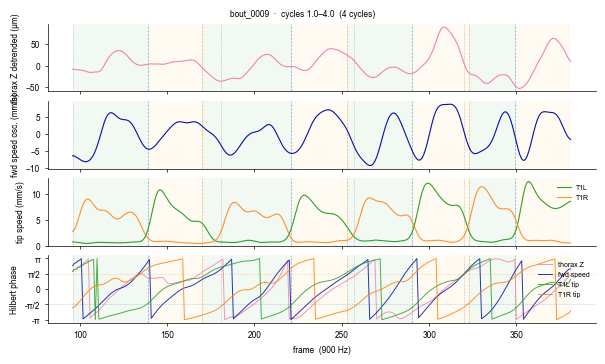

In [ ]:
## walking cycles of a chosen bout: kinematics overview

import matplotlib.font_manager as _fmd
import matplotlib as _mpld
_fmd.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/Arial.ttf")
_mpld.rcParams.update({'font.family': 'Arial', 'font.size': 6,
                        'axes.labelsize': 6, 'axes.titlesize': 6,
                        'xtick.labelsize': 6, 'ytick.labelsize': 6,
                        'pdf.fonttype': 42})

# ── Toggles ───────────────────────────────────────────────────────────────────
BOUT_ID          = 'bout_0009' # ← change me
CYCLE_START      = 1           # ← first cycle index (0-based within bout)
N_CYCLES         = None           # ← how many cycles (None = all)
SMOOTH_SIGMA_Z   = 2            # ← Gaussian σ for scutellum height (frames; 0 = off)
SMOOTH_SIGMA_FWD = 3            # ← Gaussian σ for forward velocity  (frames; 0 = off)
SMOOTH_SIGMA_TIP = 3            # ← Gaussian σ for leg tip speeds    (frames)

# ── Data window ───────────────────────────────────────────────────────────────
b = df_valid[df_valid['bout_id'] == BOUT_ID].copy()
if b.empty:
    raise ValueError(f"{BOUT_ID} not found.")

all_cyc_ids = sorted(b.dropna(subset=['step_cycle_id'])['step_cycle_id'].unique())
_end        = (CYCLE_START + N_CYCLES) if N_CYCLES is not None else len(all_cyc_ids)
cyc_ids     = all_cyc_ids[CYCLE_START:_end]
b_win       = b[b['step_cycle_id'].isin(cyc_ids)].copy()

frames = b_win['frame'].values
stance = (b_win['T1_left_swing_stance'].values.astype(float)
          if 'T1_left_swing_stance' in b_win.columns
          else np.full(len(frames), np.nan))
lo_frames = frames[np.where(np.diff(stance, prepend=stance[0]) == -1)[0]]
td_frames = frames[np.where(np.diff(stance, prepend=stance[0]) ==  1)[0]]

# ── Signal helpers ────────────────────────────────────────────────────────────
from scipy.ndimage import gaussian_filter1d as _gf1d
from scipy.signal  import hilbert as _hilbert

def _smooth(sig, sigma):
    if sigma and sigma > 0:
        fin = np.isfinite(sig)
        if (~fin).any() and fin.sum() > 1:
            sig = sig.copy()
            sig[~fin] = np.interp(np.flatnonzero(~fin), np.flatnonzero(fin), sig[fin])
        return _gf1d(sig, sigma)
    return sig

def _tip_speed(leg_prefix):
    cols = [f'{leg_prefix}_tip_{ax}_world' for ax in ('x', 'y', 'z')]
    xyz  = np.stack([b_win[c].values.astype(float) for c in cols], axis=1)
    for d in range(3):
        col = xyz[:, d]; nans = np.isnan(col)
        if nans.any() and (~nans).sum() > 1:
            col[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), col[~nans])
    spd = np.linalg.norm(np.gradient(xyz, axis=0) * FPS_IK, axis=1)
    return _smooth(spd, SMOOTH_SIGMA_TIP)

def _hilbert_phase(sig):
    s = sig - np.nanmean(sig)
    t = np.arange(len(s))
    s = s - np.polyval(np.polyfit(t, np.where(np.isnan(s), 0., s), 1), t)
    s[np.isnan(s)] = 0.
    return np.angle(_hilbert(s))

FPS_IK = 900

z_det   = _smooth(b_win['thorax_z_detrended'].values * 1000, SMOOTH_SIGMA_Z)
fwd_vel = _smooth((b_win['forward_speed'] - b_win['step_cycle_mean_speed']).values,
                  SMOOTH_SIGMA_FWD)
t1l_spd = _tip_speed('T1_left')
t1r_spd = _tip_speed('T1_right')
ph_z    = _hilbert_phase(z_det)
ph_fwd  = _hilbert_phase(fwd_vel)
ph_t1l  = _hilbert_phase(t1l_spd)
ph_t1r  = _hilbert_phase(t1r_spd)

print(f"{BOUT_ID}  cycles {cyc_ids[0]}–{cyc_ids[-1]}  {len(frames)} frames @ {FPS_IK} Hz")

# ── Shared plot helpers ───────────────────────────────────────────────────────
def _shade(ax):
    prev_f, prev_st = frames[0], stance[0]
    for k in range(1, len(frames)):
        if stance[k] != prev_st or k == len(frames) - 1:
            ax.axvspan(prev_f, frames[k], alpha=0.25,
                       color='#cce5cc' if prev_st == 1 else '#fff3cd', lw=0)
            prev_f, prev_st = frames[k], stance[k]

def _events(ax):
    for lf in lo_frames:
        ax.axvline(lf, color='#1f77b4', ls='--', lw=0.5, alpha=0.6)
    for td in td_frames:
        ax.axvline(td, color='#ff7f0e', ls='--', lw=0.5, alpha=0.6)

def _cycles(ax):
    for cid in cyc_ids:
        cf = b_win[b_win['step_cycle_id'] == cid]['frame'].values
        if len(cf):
            ax.axvline(cf[0], color='k', ls=':', lw=0.5, alpha=0.35)

# ── Figure ────────────────────────────────────────────────────────────────────
_W = 150 / 25.4
fig, axes = plt.subplots(4, 1, figsize=(_W, 4 * 22 / 25.4), sharex=True)
ax_z, ax_fwd, ax_leg, ax_ph = axes

# Panel 1 — Detrended thorax height
_shade(ax_z); _events(ax_z); _cycles(ax_z)
ax_z.plot(frames, z_det, color=HEIGHT_COLOR, lw=0.8)
ax_z.set_ylabel('thorax Z detrended (µm)')
sns.despine(ax=ax_z)

# Panel 2 — Forward velocity oscillation
_shade(ax_fwd); _events(ax_fwd); _cycles(ax_fwd)
ax_fwd.plot(frames, fwd_vel, color=SPEED_COLOR, lw=0.8)
ax_fwd.set_ylabel('fwd speed osc. (mm/s)')
sns.despine(ax=ax_fwd)

# Panel 3 — T1 leg tip speeds
_shade(ax_leg); _events(ax_leg); _cycles(ax_leg)
ax_leg.plot(frames, t1l_spd, color='#2ca02c', lw=0.8, label='T1L')
ax_leg.plot(frames, t1r_spd, color='#ff7f0e', lw=0.8, alpha=0.85, label='T1R')
ax_leg.set_ylabel('tip speed (mm/s)')
ax_leg.set_ylim(bottom=0)
ax_leg.legend(fontsize=5, frameon=False, loc='upper right')
sns.despine(ax=ax_leg)

# Panel 4 — Hilbert phase
_shade(ax_ph); _events(ax_ph); _cycles(ax_ph)
for _ph, _clr, _lbl in [
    (ph_z,   HEIGHT_COLOR, 'thorax Z'),
    (ph_fwd, SPEED_COLOR,  'fwd speed'),
    (ph_t1l, '#2ca02c',    'T1L tip'),
    (ph_t1r, '#ff7f0e',    'T1R tip'),
]:
    ax_ph.plot(frames, _ph, color=_clr, lw=0.7, alpha=0.85, label=_lbl)
ax_ph.axhline(-np.pi/2, color='#1f77b4', ls=':', lw=0.5, alpha=0.5)
ax_ph.axhline( np.pi/2, color='#ff7f0e', ls=':', lw=0.5, alpha=0.5)
ax_ph.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax_ph.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax_ph.set_ylabel('Hilbert phase')
ax_ph.set_xlabel(f'frame  ({FPS_IK} Hz)')
ax_ph.legend(fontsize=5, frameon=False, loc='upper right')
sns.despine(ax=ax_ph)

fig.suptitle(f'{BOUT_ID}  ·  cycles {cyc_ids[0]}–{cyc_ids[-1]}  ({len(cyc_ids)} cycles)',
             fontsize=6, y=1.002)
plt.tight_layout(pad=0.3, h_pad=0.4)
plt.savefig(OUTPUT_DIR / 'traces.pdf', bbox_inches='tight', dpi=300)
plt.show()
